# Main idea
An audio file format that stores audio using fourier transforms to decompose the audio into its various signals and then storing the properties of the waves.

# Steps to convert (from a wav file):
- Splits the audio into chunks (to make calculations faster)\
- Calculates the the fourier transform of each chunks
- Get each freqency from each wave from the chunk
- Write it to a file

# To reconstruct
- Sum up the waves given their frequencies
- Do an inverse fourier transform

In [54]:
# Fourier transform basic example
%pip install numpy matplotlib sympy
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

# https://stackoverflow.com/questions/4225432/how-to-compute-frequency-of-data-using-fft
SAMPLING_RATE = 999999
x_values = np.linspace(0, 1, SAMPLING_RATE)
AMOUNT_OF_SAMPLES = len(x_values)
sin_y_values = np.sin(x_values * 2 * np.pi * 30)
transformed_y_values = np.fft.fft(sin_y_values)
n0 = x_values[list(transformed_y_values).index(max(transformed_y_values))]
print(n0)
hertz = SAMPLING_RATE * n0

hertz /= AMOUNT_OF_SAMPLES
print(hertz)
print(hertz*10**np.ceil(np.log10(SAMPLING_RATE)))# 30.garbage the it gets closer and closer to the actual frequency the more samples there are


c:\Users\jalau\fourierTest\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.
3.0000060000119996e-05
3.0000060000119996e-05
30.000060000119994


The wave in this example: $\sin(2\cdot\pi\cdot10x)+\sin(2\cdot\pi\cdot15x)+\sin(2\cdot\pi\cdot20x)+\sin(2\cdot\pi\cdot25x)$

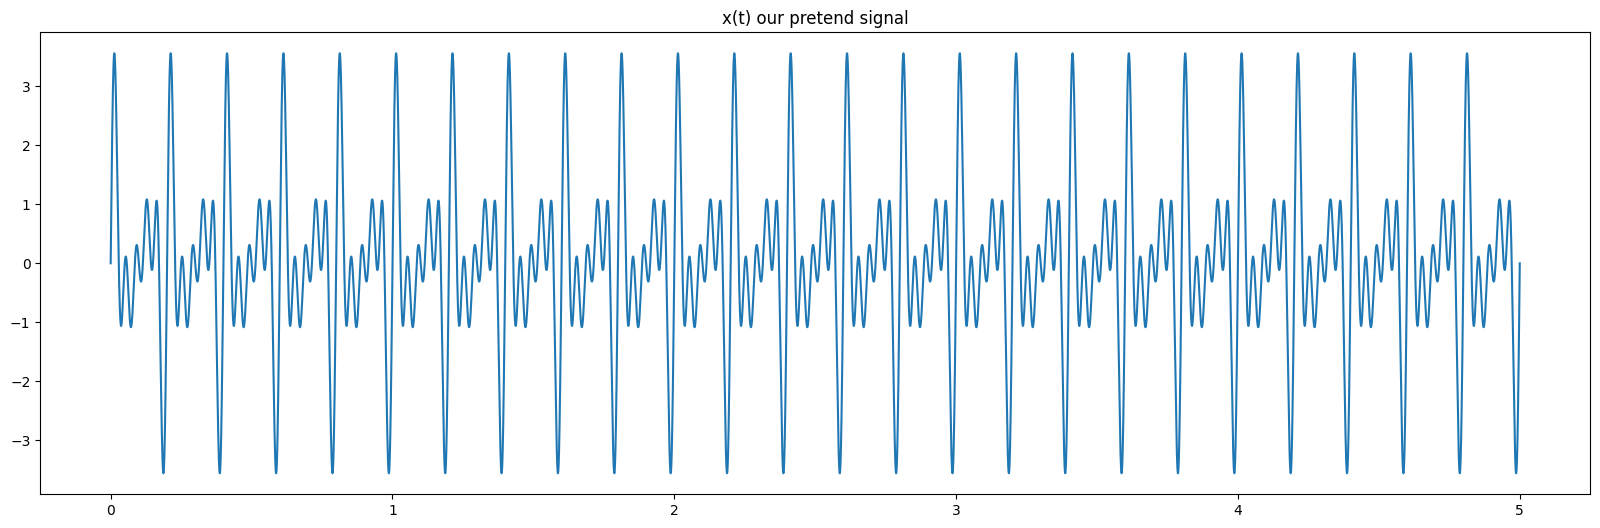

c:\Users\jalau\fourierTest\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\jalau\fourierTest\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


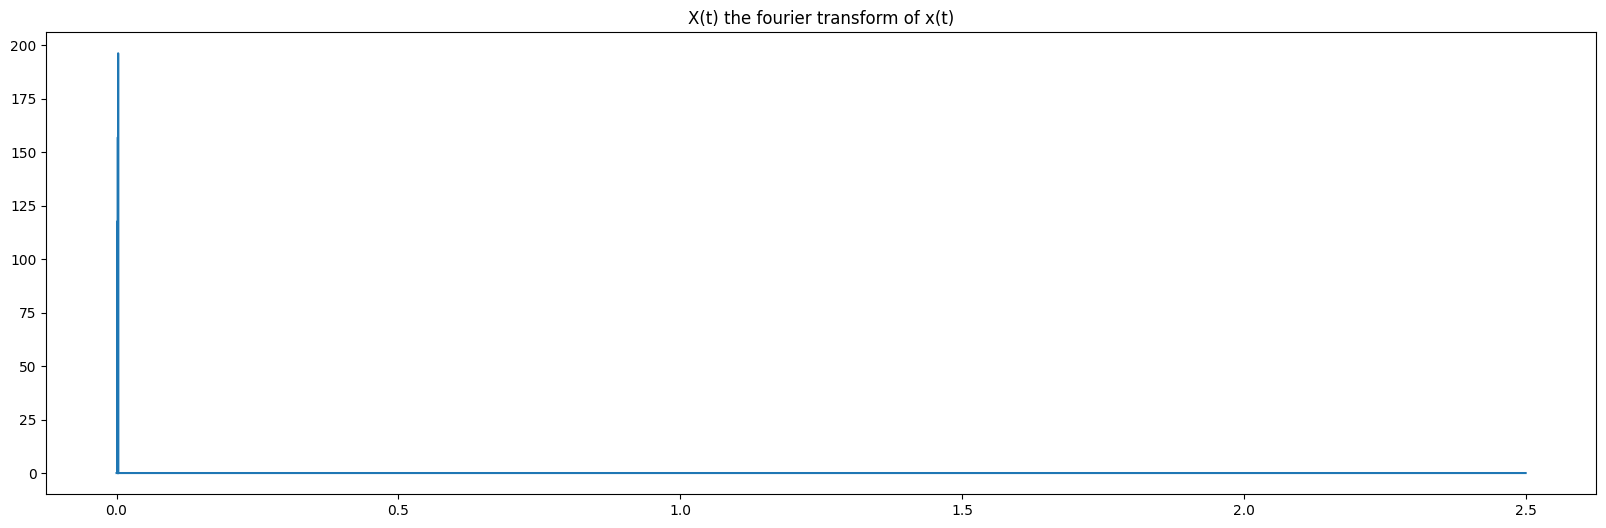

c:\Users\jalau\fourierTest\.venv\Lib\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


Peaks found:[ 78.54129395 117.8109638  157.07894394 196.34241255]
44100
0.0011337919899863493
44100
0.001700687984979524
44100
0.0022675839799726986
44100
0.0028344799749658732
[ 0.00000000e+00  4.53514739e-05  9.07029478e-05 ... -1.36054422e-04
 -9.07029478e-05 -4.53514739e-05]
[np.float64(22.675839799726987), np.float64(34.01375969959048), np.float64(45.35167959945397), np.float64(56.68959949931747)]


In [68]:
# A more complex example
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
def x(t):
    return (np.sin(2 * np.pi * 10 * t) +
     np.sin(2 * np.pi * 15 * t) +
     np.sin(2 * np.pi * 20 * t) +
     np.sin(2 * np.pi * 25 * t))
    
SAMPLING_RATE = 44_100
LENGTH_IN_SECONDS = 5
AMOUNT_OF_SAMPLES = LENGTH_IN_SECONDS * SAMPLING_RATE
x_values = np.linspace(0, LENGTH_IN_SECONDS, AMOUNT_OF_SAMPLES)
y = x(x_values)

plt.figure(figsize=(20, 6))
plt.title("x(t) our pretend signal")
plt.plot(x_values,y)
plt.show()
fft = np.fft.fft(y)
# remove the negative parts
fft = fft[range(int(len(fft)/2))]
plt.figure(figsize=(20, 6))
plt.title("X(t) the fourier transform of x(t)")
plt.plot(x_values[range(int(len(x_values)/2))], fft)
plt.show()
peaks = find_peaks(fft, 50)
peaks = peaks[1]["peak_heights"]
print("Peaks found:" + str(peaks))
freqs = []
fft = np.real(fft)
for peak in peaks:
    n0 = x_values[list(fft).index(np.real(peak))]
    print(SAMPLING_RATE)
    print(n0)
    hertz = n0 * SAMPLING_RATE
    hertz /= AMOUNT_OF_SAMPLES
    freqs.append(hertz*10**np.ceil(np.log10(SAMPLING_RATE)))
    
np.fft.fftfreq
print(np.fft.fftfreq(y.size, d=0.1))
print(freqs)



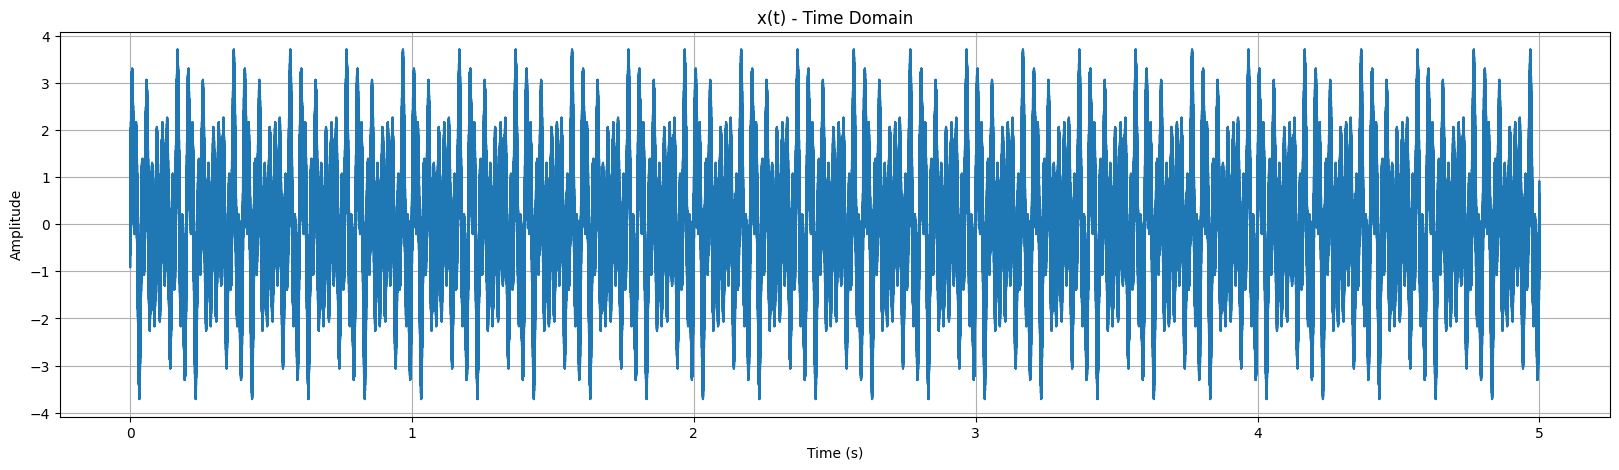

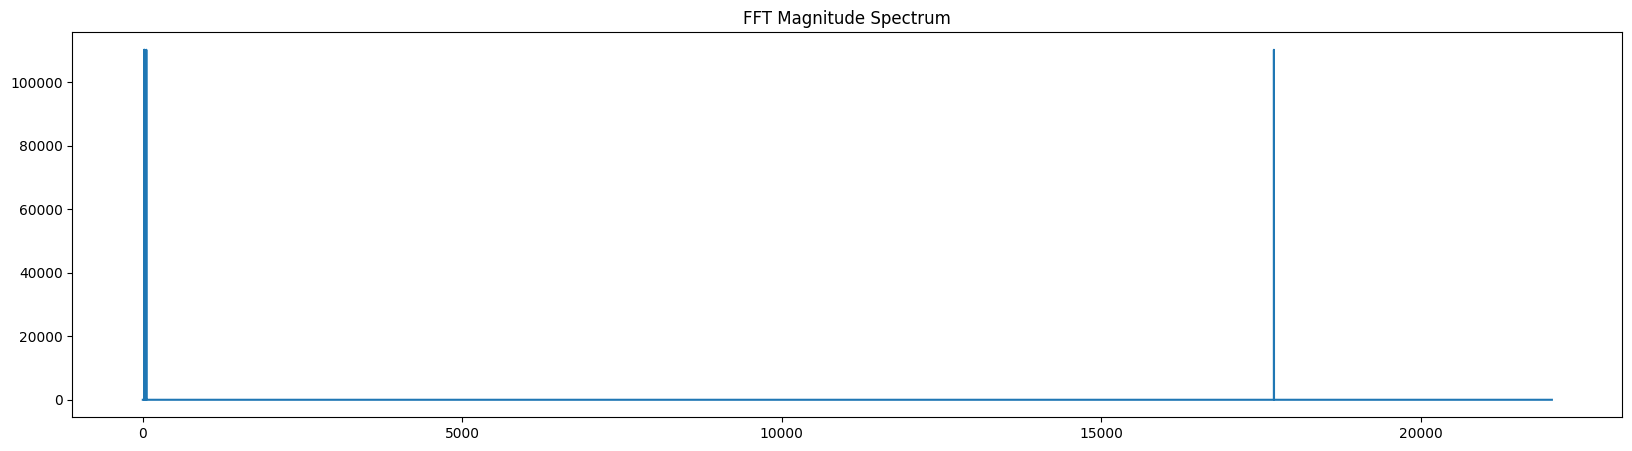

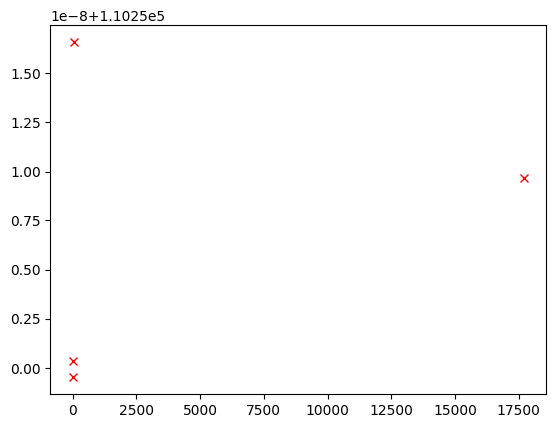

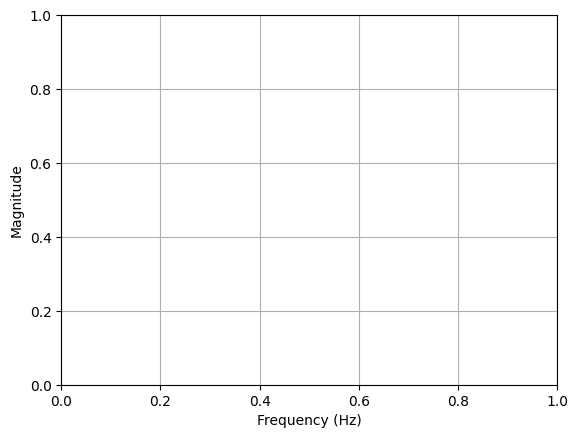

Detected frequencies:
20.0 Hz
25.0 Hz
55.0 Hz
17700.0 Hz


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def x(t):
    return (np.sin(2 * np.pi * 55 * t) +
            np.sin(2 * np.pi * 150000 * t) +
            np.sin(2 * np.pi * 20 * t) +
            np.sin(2 * np.pi * 25 * t))
SAMPLING_RATE = 44100
DURATION = 5
SAMPLES = SAMPLING_RATE * DURATION
t = np.linspace(0, DURATION, SAMPLES, endpoint=False)
y = x(t)
fft_result = np.fft.fft(y)
fft_magnitude = np.abs(fft_result[:SAMPLES // 2])
frequencies = np.fft.fftfreq(SAMPLES, d=1/SAMPLING_RATE)[:SAMPLES // 2]
peaks, props = find_peaks(fft_magnitude, height=10000) 
plt.figure(figsize=(20, 5))
plt.title("x(t) - Time Domain")
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()
plt.figure(figsize=(20, 5))
plt.title("FFT Magnitude Spectrum")
plt.plot(frequencies, fft_magnitude)
plt.show()
plt.plot(frequencies[peaks], fft_magnitude[peaks], "rx")
plt.show()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()
print("Detected frequencies:")
for p in peaks:
    print(f"{frequencies[p]} Hz")